In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Config ──────────────────────────────────────────────────────────────────
IMG_SIZE    = 128
BATCH_SIZE  = 16
EPOCHS      = 30
NUM_CLASSES = 4
LR          = 1e-4
FREEZE_FRAC = 0.5   # freeze first 50% of layers

DATASET_PATH = r"D:\brain_tumor_project\dataset"
SAVE_DIR     = r"D:\brain_tumor_project\models"
os.makedirs(SAVE_DIR, exist_ok=True)

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'Training'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)
val_gen = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'Training'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)
test_gen = test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'Testing'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
print("Train:", train_gen.samples, "| Val:", val_gen.samples, "| Test:", test_gen.samples)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Train: 4480 | Val: 1120 | Test: 1600


In [3]:
def se_block(x, ratio=16):
    """Squeeze-and-Excitation block."""
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Reshape((1, 1, filters))(se)
    se = layers.Dense(filters // ratio, activation='relu', use_bias=False)(se)
    se = layers.Dense(filters, activation='sigmoid', use_bias=False)(se)
    return layers.Multiply()([x, se])

def cbam_block(x, ratio=16):
    """CBAM: Channel + Spatial attention."""
    filters = x.shape[-1]
    # Channel attention
    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)
    avg_pool = layers.Reshape((1, 1, filters))(avg_pool)
    max_pool = layers.Reshape((1, 1, filters))(max_pool)
    shared_fc1 = layers.Dense(filters // ratio, activation='relu', use_bias=False)
    shared_fc2 = layers.Dense(filters, use_bias=False)
    avg_out = shared_fc2(shared_fc1(avg_pool))
    max_out = shared_fc2(shared_fc1(max_pool))
    channel_att = layers.Activation('sigmoid')(layers.Add()([avg_out, max_out]))
    x = layers.Multiply()([x, channel_att])
    # Spatial attention
    avg_sp = layers.Lambda(lambda t: tf.reduce_mean(t, axis=-1, keepdims=True))(x)
    max_sp = layers.Lambda(lambda t: tf.reduce_max(t, axis=-1, keepdims=True))(x)
    spatial = layers.Concatenate(axis=-1)([avg_sp, max_sp])
    spatial = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(spatial)
    return layers.Multiply()([x, spatial])

In [8]:
class SaveBestModel(tf.keras.callbacks.Callback):
    def __init__(self, filepath, monitor='val_accuracy'):
        super().__init__()
        self.filepath = filepath
        self.monitor = monitor
        self.best = -np.inf

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor, -np.inf)
        if current > self.best:
            self.best = current
            self.model.save_weights(self.filepath.replace('.keras', '.weights.h5'))
            print(f"\n  ✓ Saved best model (val_acc={current:.4f}) → {self.filepath}")

In [5]:
def build_efficientnet(attention='none'):
    """
    attention: 'none' | 'se' | 'cbam'
    """
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    
    base = EfficientNetB5(include_top=False, weights='imagenet', input_tensor=inputs)
    
    # Freeze first 50% of layers
    n_layers = len(base.layers)
    freeze_until = int(n_layers * FREEZE_FRAC)
    for layer in base.layers[:freeze_until]:
        layer.trainable = False
    for layer in base.layers[freeze_until:]:
        layer.trainable = True
    
    x = base.output
    
    # Apply attention
    if attention == 'se':
        x = se_block(x, ratio=16)
    elif attention == 'cbam':
        x = cbam_block(x, ratio=16)
    # 'none' → no attention block
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = Model(inputs, outputs)
    return model

In [6]:
def train_model(attention_type, model_id):
    print(f"\n{'='*60}")
    print(f"  Training: EfficientNetB5 + {attention_type.upper()}  [{model_id}]")
    print(f"{'='*60}")
    
    model = build_efficientnet(attention=attention_type)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    print(f"  Total params: {model.count_params():,}")
    
    save_path = os.path.join(SAVE_DIR, f"efficientnet_{attention_type}_{IMG_SIZE}.keras")
    callbacks = [
        SaveBestModel(filepath=save_path, monitor='val_accuracy'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
    ]
    
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=callbacks
    )
    return model, history, save_path

def plot_history(history, model_id):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(history.history['accuracy'],     label='Train Acc')
    ax1.plot(history.history['val_accuracy'], label='Val Acc')
    ax1.set_title(f'{model_id} — Accuracy'); ax1.legend(); ax1.grid(True)
    ax2.plot(history.history['loss'],     label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title(f'{model_id} — Loss'); ax2.legend(); ax2.grid(True)
    plt.tight_layout()
    fig.savefig(os.path.join(SAVE_DIR, f"{model_id}_training_curves.png"), dpi=150)
    plt.show()
    print(f"  Saved training curves.")

def evaluate_model(model, model_id):
    test_gen.reset()
    loss, acc = model.evaluate(test_gen, verbose=0)
    print(f"\n  Test Accuracy [{model_id}]: {acc*100:.2f}%  |  Loss: {loss:.4f}")
    
    test_gen.reset()
    preds = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes
    
    print("\n  Classification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix — {model_id}')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"{model_id}_confusion_matrix.png"), dpi=150)
    plt.show()
    return acc


  Training: EfficientNetB5 + NONE  [A1]
  Total params: 29,047,291
Epoch 1/30
280/280 [==============================] - ETA: 0s - loss: 1.3970 - accuracy: 0.4944
  ✓ Saved best model (val_acc=0.4830) → D:\brain_tumor_project\models\efficientnet_none_128.keras
280/280 [==============================] - 70s 169ms/step - loss: 1.3970 - accuracy: 0.4944 - val_loss: 1.1891 - val_accuracy: 0.4830 - lr: 1.0000e-04
Epoch 2/30
280/280 [==============================] - ETA: 0s - loss: 1.1476 - accuracy: 0.5688
  ✓ Saved best model (val_acc=0.6446) → D:\brain_tumor_project\models\efficientnet_none_128.keras
280/280 [==============================] - 44s 158ms/step - loss: 1.1476 - accuracy: 0.5688 - val_loss: 0.9103 - val_accuracy: 0.6446 - lr: 1.0000e-04
Epoch 3/30
280/280 [==============================] - ETA: 0s - loss: 0.9987 - accuracy: 0.6134
  ✓ Saved best model (val_acc=0.7071) → D:\brain_tumor_project\models\efficientnet_none_128.keras
280/280 [==============================] - 45s 1

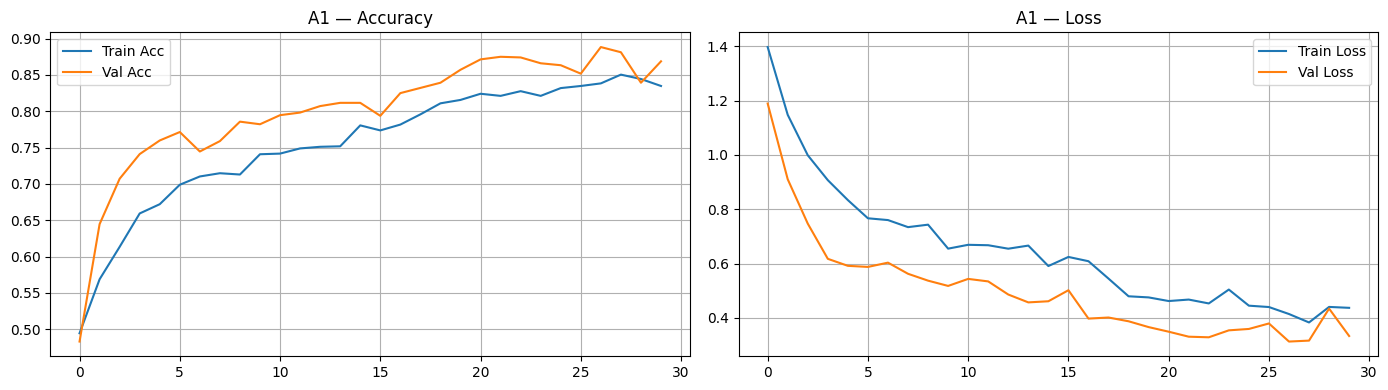

  Saved training curves.

  Test Accuracy [A1]: 86.69%  |  Loss: 0.5421

  Classification Report:
              precision    recall  f1-score   support

      glioma       0.94      0.64      0.76       400
  meningioma       0.75      0.92      0.83       400
     notumor       0.87      0.99      0.93       400
   pituitary       0.96      0.92      0.94       400

    accuracy                           0.87      1600
   macro avg       0.88      0.87      0.86      1600
weighted avg       0.88      0.87      0.86      1600



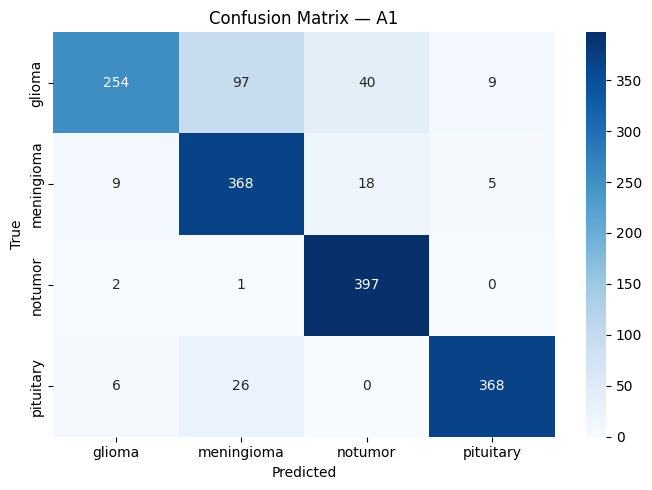

NameError: name 'results' is not defined

In [9]:
# A1 — EfficientNetB5 Baseline (no attention)
model_a1, hist_a1, _ = train_model('none', 'A1')
plot_history(hist_a1, 'A1')
results['A1 - EfficientNetB5 Base'] = evaluate_model(model_a1, 'A1')

In [10]:
results = {}
results['A1 - EfficientNetB5 Base'] = 0.8669


  Training: EfficientNetB5 + SE  [A2]
  Total params: 29,571,579
Epoch 1/30
280/280 [==============================] - ETA: 0s - loss: 1.3710 - accuracy: 0.4955
  ✓ Saved best model (val_acc=0.4304) → D:\brain_tumor_project\models\efficientnet_se_128.keras
280/280 [==============================] - 71s 175ms/step - loss: 1.3710 - accuracy: 0.4955 - val_loss: 1.2547 - val_accuracy: 0.4304 - lr: 1.0000e-04
Epoch 2/30
280/280 [==============================] - ETA: 0s - loss: 1.1379 - accuracy: 0.5670
  ✓ Saved best model (val_acc=0.6634) → D:\brain_tumor_project\models\efficientnet_se_128.keras
280/280 [==============================] - 46s 164ms/step - loss: 1.1379 - accuracy: 0.5670 - val_loss: 0.8272 - val_accuracy: 0.6634 - lr: 1.0000e-04
Epoch 3/30
280/280 [==============================] - ETA: 0s - loss: 1.0199 - accuracy: 0.6143
  ✓ Saved best model (val_acc=0.6991) → D:\brain_tumor_project\models\efficientnet_se_128.keras
280/280 [==============================] - 46s 165ms/ste

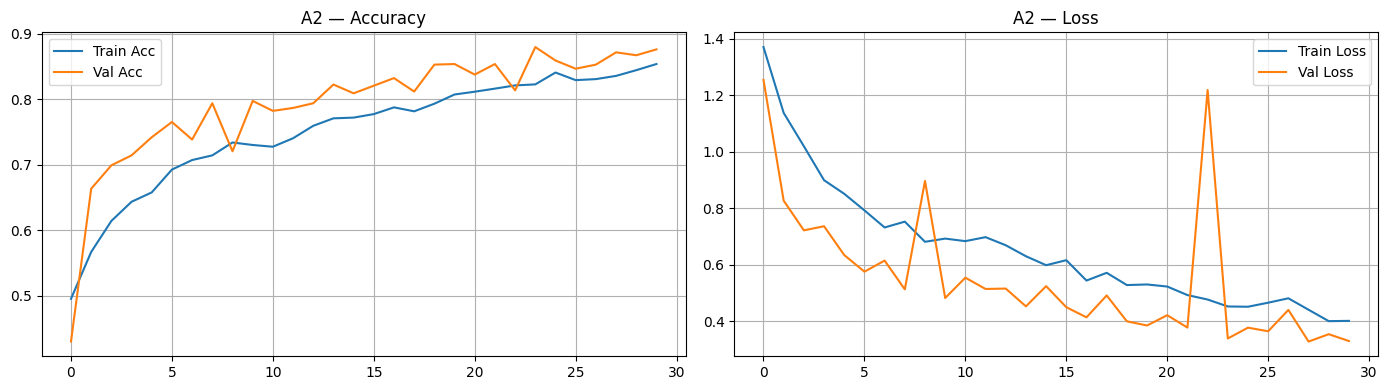

  Saved training curves.

  Test Accuracy [A2]: 85.44%  |  Loss: 0.6023

  Classification Report:
              precision    recall  f1-score   support

      glioma       0.92      0.63      0.75       400
  meningioma       0.78      0.84      0.81       400
     notumor       0.83      0.99      0.90       400
   pituitary       0.91      0.95      0.93       400

    accuracy                           0.85      1600
   macro avg       0.86      0.85      0.85      1600
weighted avg       0.86      0.85      0.85      1600



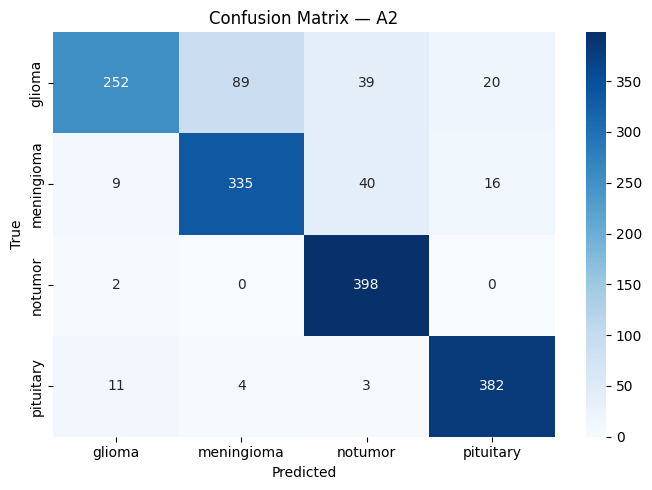

In [11]:
model_a2, hist_a2, _ = train_model('se', 'A2')
plot_history(hist_a2, 'A2')
results['A2 - EfficientNetB5 SE'] = evaluate_model(model_a2, 'A2')


  Training: EfficientNetB5 + CBAM  [A3]
  Total params: 29,571,678
Epoch 1/30
280/280 [==============================] - ETA: 0s - loss: 1.4205 - accuracy: 0.4833
  ✓ Saved best model (val_acc=0.4554) → D:\brain_tumor_project\models\efficientnet_cbam_128.keras
280/280 [==============================] - 84s 201ms/step - loss: 1.4205 - accuracy: 0.4833 - val_loss: 1.2019 - val_accuracy: 0.4554 - lr: 1.0000e-04
Epoch 2/30
280/280 [==============================] - ETA: 0s - loss: 1.1241 - accuracy: 0.5737
  ✓ Saved best model (val_acc=0.6821) → D:\brain_tumor_project\models\efficientnet_cbam_128.keras
280/280 [==============================] - 55s 195ms/step - loss: 1.1241 - accuracy: 0.5737 - val_loss: 0.7666 - val_accuracy: 0.6821 - lr: 1.0000e-04
Epoch 3/30
280/280 [==============================] - ETA: 0s - loss: 0.9606 - accuracy: 0.6196
  ✓ Saved best model (val_acc=0.7080) → D:\brain_tumor_project\models\efficientnet_cbam_128.keras
280/280 [==============================] - 49s 1

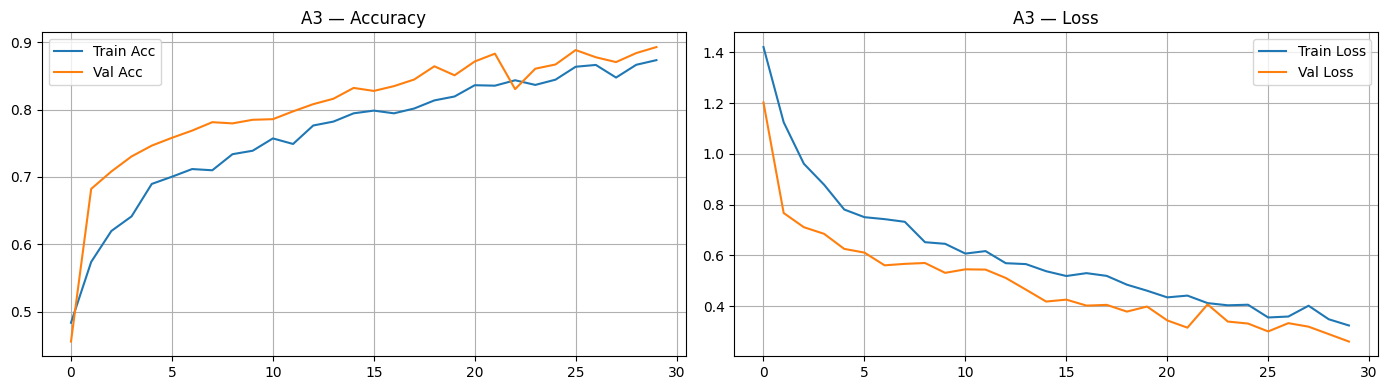

  Saved training curves.

  Test Accuracy [A3]: 88.25%  |  Loss: 0.6272

  Classification Report:
              precision    recall  f1-score   support

      glioma       0.94      0.67      0.78       400
  meningioma       0.80      0.90      0.85       400
     notumor       0.87      1.00      0.93       400
   pituitary       0.95      0.97      0.96       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600



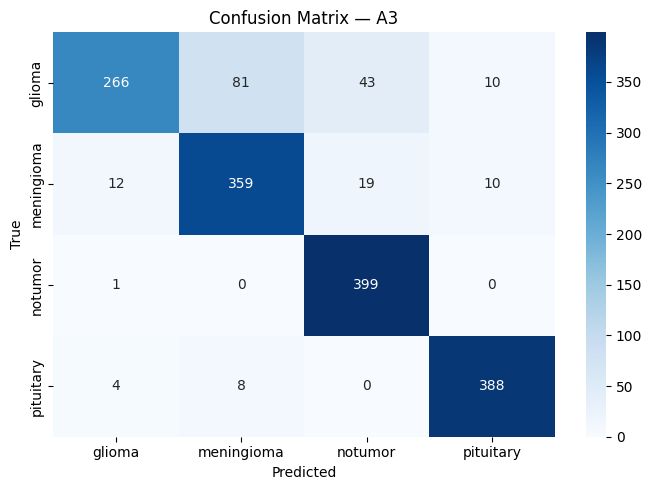

In [12]:
model_a3, hist_a3, _ = train_model('cbam', 'A3')
plot_history(hist_a3, 'A3')
results['A3 - EfficientNetB5 CBAM'] = evaluate_model(model_a3, 'A3')

In [13]:
print("\n" + "="*50)
print("  EFFICIENTNET RESULTS SUMMARY")
print("="*50)
for name, acc in results.items():
    print(f"  {name:35s}  {acc*100:.2f}%" if isinstance(acc, float) and acc < 2 else f"  {name:35s}  {acc:.2f}%")


  EFFICIENTNET RESULTS SUMMARY
  A1 - EfficientNetB5 Base             86.69%
  A2 - EfficientNetB5 SE               85.44%
  A3 - EfficientNetB5 CBAM             88.25%
